<a href="https://colab.research.google.com/github/IrumShehryar/ML-NLP-Coursework/blob/main/nlp/04-neural-network/neural-word-embeddings/Project03_TextClassification_Neural_Embeddings_GloVe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [2]:
!pip install gensim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
from sklearn.model_selection import train_test_split
from gensim.models import KeyedVectors
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.5 MB/s eta 0:00:00


# Read the dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
%cd /content/drive/MyDrive/NLP-course/Course Material/Neural Word Embeddings (GloVe)

/content/drive/MyDrive/NLP-course/Course Material/Neural Word Embeddings (GloVe)


In [6]:
df = pd.read_csv('moviereviews.tsv', sep='\t')

In [7]:
df

,label,review
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...
3,pos,according to hollywood movies made in last few...
4,neg,my first press screening of 1998 and already i...
...,...,...
1995,pos,"i like movies with albert brooks , and i reall..."
1996,pos,it might surprise some to know that joel and e...
1997,pos,the verdict : spine-chilling drama from horror...
1998,pos,i want to correct what i wrote in a former ret...



# Check the Null Values

In [8]:
df.isnull().any()

,0
label,False
review,True


In [9]:
df.dropna(inplace = True)

In [10]:
df.isnull().any()

,0
label,False
review,False


# Check if the data is balance

In [11]:
df['label'].value_counts()

,count
label,
neg,983
pos,982


# Change the columns name to labels and text

In [12]:
df.columns = ['labels', 'text']

# Convert labels to integers

In [13]:
df['labels'] = df['labels'].map({'pos': 0, 'neg': 1})

In [14]:
df.head()

,labels,text
0,1,how do films like mouse hunt get into theatres...
1,1,some talented actresses are blessed with a dem...
2,0,this has been an extraordinary year for austra...
3,0,according to hollywood movies made in last few...
4,1,my first press screening of 1998 and already i...


# Extract features and labels

In [15]:
features = df['text']
labels = df['labels']

# Split the data into training and testing

In [16]:
train_data, test_data, train_labels, test_labels = train_test_split(features, labels, test_size = 0.2, random_state = 42)

# Import Glove Vectorizer

In [17]:
from GloveVectorizer import GloveVectorizer

In [18]:
vectorizer = GloveVectorizer()

Loading word vectors...
Found 400000 word vectors.


# Vectorize Training and Testing data

In [19]:
Xtrain = vectorizer.fit_transform(train_data)
Xtest = vectorizer.transform(test_data)

Numer of samples with no words found: 21 / 1572
Numer of samples with no words found: 6 / 393


In [20]:
type(Xtrain)

numpy.ndarray

# Feature dimension of the input data

In [21]:
D = Xtrain.shape[1]
print(D)

50


# Create the model and train it

In [22]:
model = Sequential()
model.add(Dense(units = 64, input_shape =(D, ), activation = 'relu'))
model.add(Dense(units = 32, activation = 'relu'))
model.add(Dense(units = 2, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
model.compile(optimizer = tf.keras.optimizers.SGD(learning_rate = 0.0001) ,loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [49]:
train = model.fit(
  Xtrain, train_labels,
  validation_data=(Xtest, test_labels),
  epochs = 50,
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7487 - loss: 0.5083 - val_accuracy: 0.7405 - val_loss: 0.5491
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7494 - loss: 0.5084 - val_accuracy: 0.7405 - val_loss: 0.5490
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7506 - loss: 0.5084 - val_accuracy: 0.7405 - val_loss: 0.5489
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7500 - loss: 0.5084 - val_accuracy: 0.7379 - val_loss: 0.5489
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7500 - loss: 0.5083 - val_accuracy: 0.7379 - val_loss: 0.5489
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7487 - loss: 0.5083 - val_accuracy: 0.7379 - val_loss: 0.5489
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7500 - loss: 0.5083 - val_accuracy: 0.7379 - val_loss: 0.5490
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7494 - loss: 0.5083 - val_accuracy: 0.7405 - val_loss:

In [50]:
trainAcc = [100 * x for x in train.history['accuracy']]
testAcc = [100 * x for x in train.history['val_accuracy']]

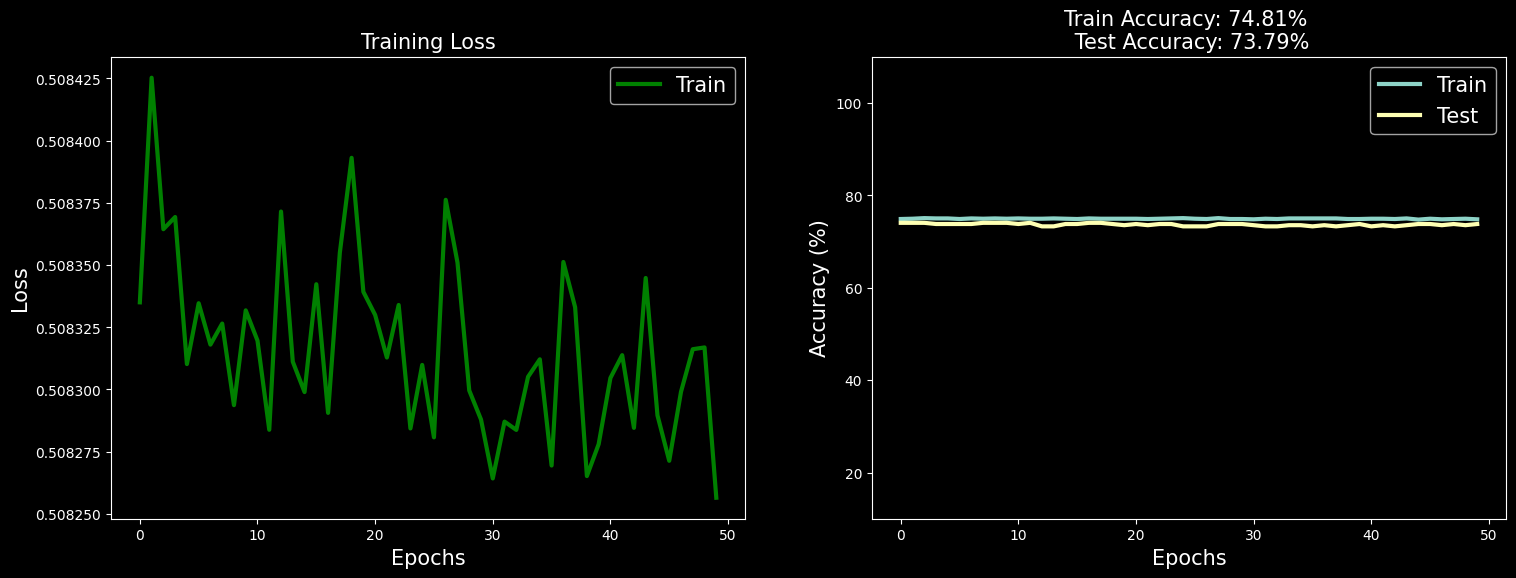

In [51]:
fig,ax = plt.subplots(1,2,figsize=(18,6))

ax[0].plot(train.history['loss'], 'g', lw = 3, label = 'Train')
ax[0].set_xlabel('Epochs', fontsize = 15)
ax[0].set_ylabel('Loss', fontsize = 15)
ax[0].legend(fontsize = 15)
ax[0].set_title('Training Loss', fontsize = 15)


ax[1].plot(trainAcc, label ='Train', lw = 3)
ax[1].plot(testAcc, label ='Test', lw = 3)
ax[1].set_xlabel('Epochs', fontsize = 15)
ax[1].set_ylabel('Accuracy (%)', fontsize = 15)
ax[1].set_ylim([10,110])
ax[1].set_title(f'Train Accuracy: {trainAcc[-1]:.2f}% \n Test Accuracy: {testAcc[-1]:.2f}%', fontsize = 15)
ax[1].legend(fontsize = 15)

plt.show()